# LeetCode #9: Palindrome Number

https://leetcode.com/problems/palindrome-number/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (String Conversion)** | $O(\log n)$ | $O(\log n)$ |
| **Reverse Half the Number** ★ | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (String Conversion)
Convert x to a string and check if it equals its reverse. Simple to write but allocates two string objects of size $O(\log n)$ on the heap.

### Optimal: Reverse Half the Number ★
Only reverse the **second half** of the digits and compare with the first half. Stop the loop when `revHalf >= x` — at that point exactly half the digits have been reversed. For even-length numbers check `x == revHalf`; for odd-length check `x == revHalf / 10` (the middle digit ends up in revHalf and must be discarded).

**Why this is better than String Conversion:** Same $O(\log n)$ time but $O(1)$ space — only two integers are ever allocated. Also avoids the overflow risk of reversing the full number (a large non-palindrome's reverse can exceed INT_MAX).

**Special guards required (both must come before the loop):**
* `if (x < 0) return false` — negative numbers are never palindromes
* `if (x != 0 && x % 10 == 0) return false` — any non-zero number ending in 0 can't be a palindrome (its reverse would have a leading zero, changing the value)

**Constraints:**
* `-2^31 <= x <= 2^31 - 1`

## Solutions

### C#

In [ ]:
public class Solution {
    public bool IsPalindrome(int x) {
        // Negatives and non-zero numbers ending in 0 are never palindromes
        if (x < 0 || (x != 0 && x % 10 == 0)) return false;

        int revHalf = 0;
        // Reverse only the second half — stop when revHalf has caught up to x
        while (x > revHalf) {
            revHalf = revHalf * 10 + x % 10;
            x /= 10;
        }

        // Even-length: x == revHalf; Odd-length: discard the middle digit with / 10
        return x == revHalf || x == revHalf / 10;
    }
}

### Python

In [ ]:
class Solution:
    def isPalindrome(self, x: int) -> bool:
        # Negatives and non-zero numbers ending in 0 are never palindromes
        if x < 0 or (x != 0 and x % 10 == 0):
            return False

        rev_half = 0
        # Reverse only the second half — stop when rev_half has caught up to x
        while x > rev_half:
            rev_half = rev_half * 10 + x % 10
            x //= 10

        # Even-length: x == rev_half; Odd-length: discard the middle digit with // 10
        return x == rev_half or x == rev_half // 10

### Go

In [ ]:
func isPalindrome(x int) bool {
    // Negatives and non-zero numbers ending in 0 are never palindromes
    if x < 0 || (x != 0 && x%10 == 0) {
        return false
    }

    revHalf := 0
    // Reverse only the second half — stop when revHalf has caught up to x
    for x > revHalf {
        revHalf = revHalf*10 + x%10
        x /= 10
    }

    // Even-length: x == revHalf; Odd-length: discard the middle digit with / 10
    return x == revHalf || x == revHalf/10
}

### Rust

In [ ]:
impl Solution {
    pub fn is_palindrome(x: i32) -> bool {
        // Negatives and non-zero numbers ending in 0 are never palindromes
        if x < 0 || (x != 0 && x % 10 == 0) {
            return false;
        }

        let (mut x, mut rev_half) = (x, 0i32);
        // Reverse only the second half — stop when rev_half has caught up to x
        while x > rev_half {
            rev_half = rev_half * 10 + x % 10;
            x /= 10;
        }

        // Even-length: x == rev_half; Odd-length: discard the middle digit with / 10
        x == rev_half || x == rev_half / 10
    }
}

## Example Scenarios

### 1. Common Case (Odd-Length Palindrome)
**Input:** `x = 121`  
Two iterations: pop 1 (revHalf=1, x=12), pop 2 (revHalf=12, x=1). Stop because 12 ≥ 1. Odd-length check: `x (1) == revHalf/10 (12/10=1)` → true.  
**Result:** `true`

### 2. Slightly Complex (Even-Length Palindrome)
**Input:** `x = 1221`  
Two iterations: pop 1 (revHalf=1, x=122), pop 2 (revHalf=12, x=12). Stop because 12 ≥ 12. Even-length check: `x (12) == revHalf (12)` → true. No middle digit to discard.  
**Result:** `true`

### 3. Edge Case: Time Factor (Largest 32-bit Palindrome)
**Input:** `x = 2147447412`  
Five iterations to reverse the right half (2·1·4·7·4 → revHalf=21474). Stop when x=21474 equals revHalf=21474. This is the maximum work the algorithm can do — $\lfloor \log_{10}(n)/2 \rfloor + 1 = 5$ iterations for a 10-digit number.  
**Result:** `true`

### 4. Edge Case: Space Factor (Negative Number)
**Input:** `x = -121`  
The guard `x < 0` fires before any loop iterations. Zero heap allocations — $O(1)$ space. The string approach would still allocate a string object on the heap before detecting the minus sign.  
**Result:** `false`

### 5. Almost-Impossible but Plausible: The Trailing-Zero Trap
**Input:** `x = 10`  
Without the guard `x != 0 && x % 10 == 0 → return false`, the loop runs: pop 0 (revHalf=0, x=1), then pop 1 (revHalf=1, x=0), odd check: 0 == 1/10 = 0 → **incorrectly returns true**. The guard is essential — any non-zero number ending in 0 would produce a leading-zero reversal, which is never equal to the original.  
**Result:** `false`

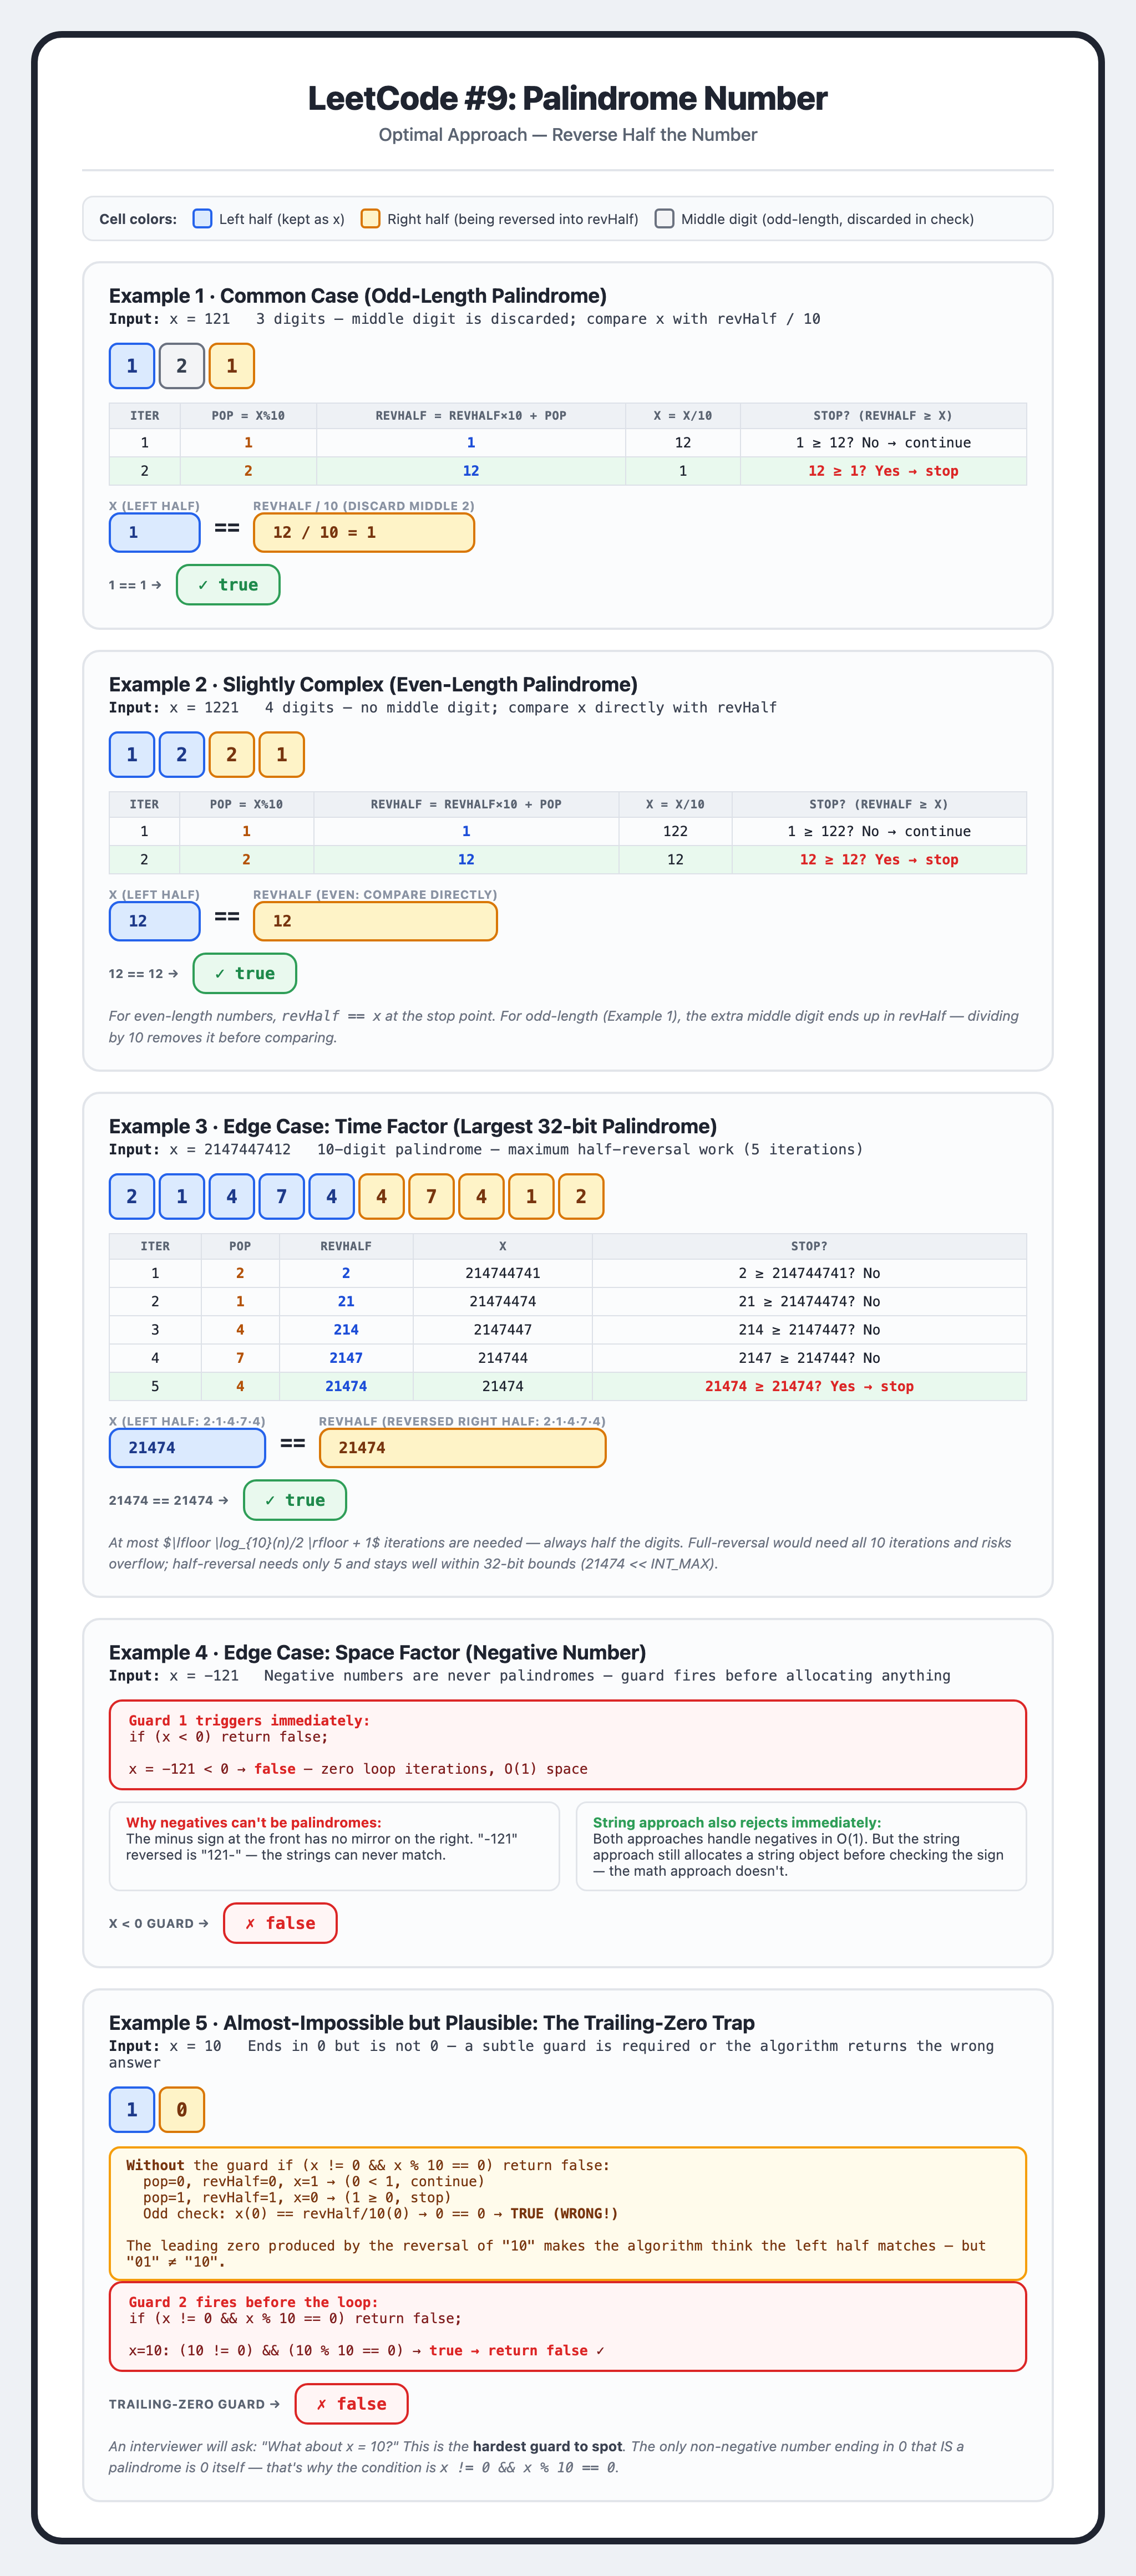